In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pickle

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic
from trianglechain import TriangleChain

from msfm.utils import logger, files, scales, power_spectra, parameters, observation

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset, input_output

# v13

In [3]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v13/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v13/extended"
# mocks = ["Buzzard", "Cardinal"]

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )

# # # label = "16mpc"
# # # label = "20mpc"
# # # label = "24mpc"
# # # label = "28mpc"
# # label = "32mpc"
# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v13/clustering/smoothing_fwhm/dlss_{label}.yaml"
# # )

# # label = "8mpc_sanity_check"
# label = "8mpc"
# # label = "12mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v13/lensing/smoothing_fwhm/dlss_{label}.yaml"
# )

# # label += "_octant"
# label += "_sanity"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v13"
# # out_dir += "/octant"

In [4]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [5]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# v14

In [7]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v14/extended"
mocks = ["Buzzard"]
# mocks = ["Buzzard", "Cardinal"]

out_dir = "/pscratch/sd/a/athomsen/run_files/v14"
# out_dir += "/octant"

### lensing

In [8]:
with_lensing = True
with_clustering = False
with_cross_z = True
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
mocks = []

label = "8mpc"
# label = "12mpc"
dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v14/lensing/smoothing_fwhm/dlss_{label}.yaml"
)

25-05-15 23:27:24 configuratio INF   Loaded the config 


### clustering

In [9]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# # label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# label = "32mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v14/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )

### combined

In [10]:
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# label = "8,32mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v14/combined/dlss_{label}.yaml"
# )

# constants

In [11]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

cosine_decay = False
# n_steps = 100_000
# checkpoint_number = 1

n_steps = 200_000
# n_steps = 300_000

out_dir = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}")

if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

print("base_dir = ", base_dir)
print("out_dir = ", out_dir)

base_dir =  /pscratch/sd/a/athomsen/v11desy3/v14/extended
out_dir =  /pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc


# white noise dset

25-05-15 23:27:26 configuratio INF   Loaded the config 
25-05-15 23:27:26 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 113.9, 77.8, 59.6, 49.9] from the dlss config 
25-05-15 23:27:26 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.78257, 0.31326, 0.23333, 0.21634] from the dlss config 
25-05-15 23:27:26 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  94.82001756
 138.81748072 181.20805369 216.43286573] from the dlss config 
25-05-15 23:27:26 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
25-05-15 23:27:26 preprocessin INF   Using n_bins = 33 from the msfm config 
25-05-15 23:27:26 preprocessin INF   Loading the pre-binned Cls 
25-05-15 23:27:26 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v14/extended 
25-05-15 23:27:26 input_output INF   Array shapes: 
25-05-15 23:27:26 input_output INF   fiducial/i_example = (

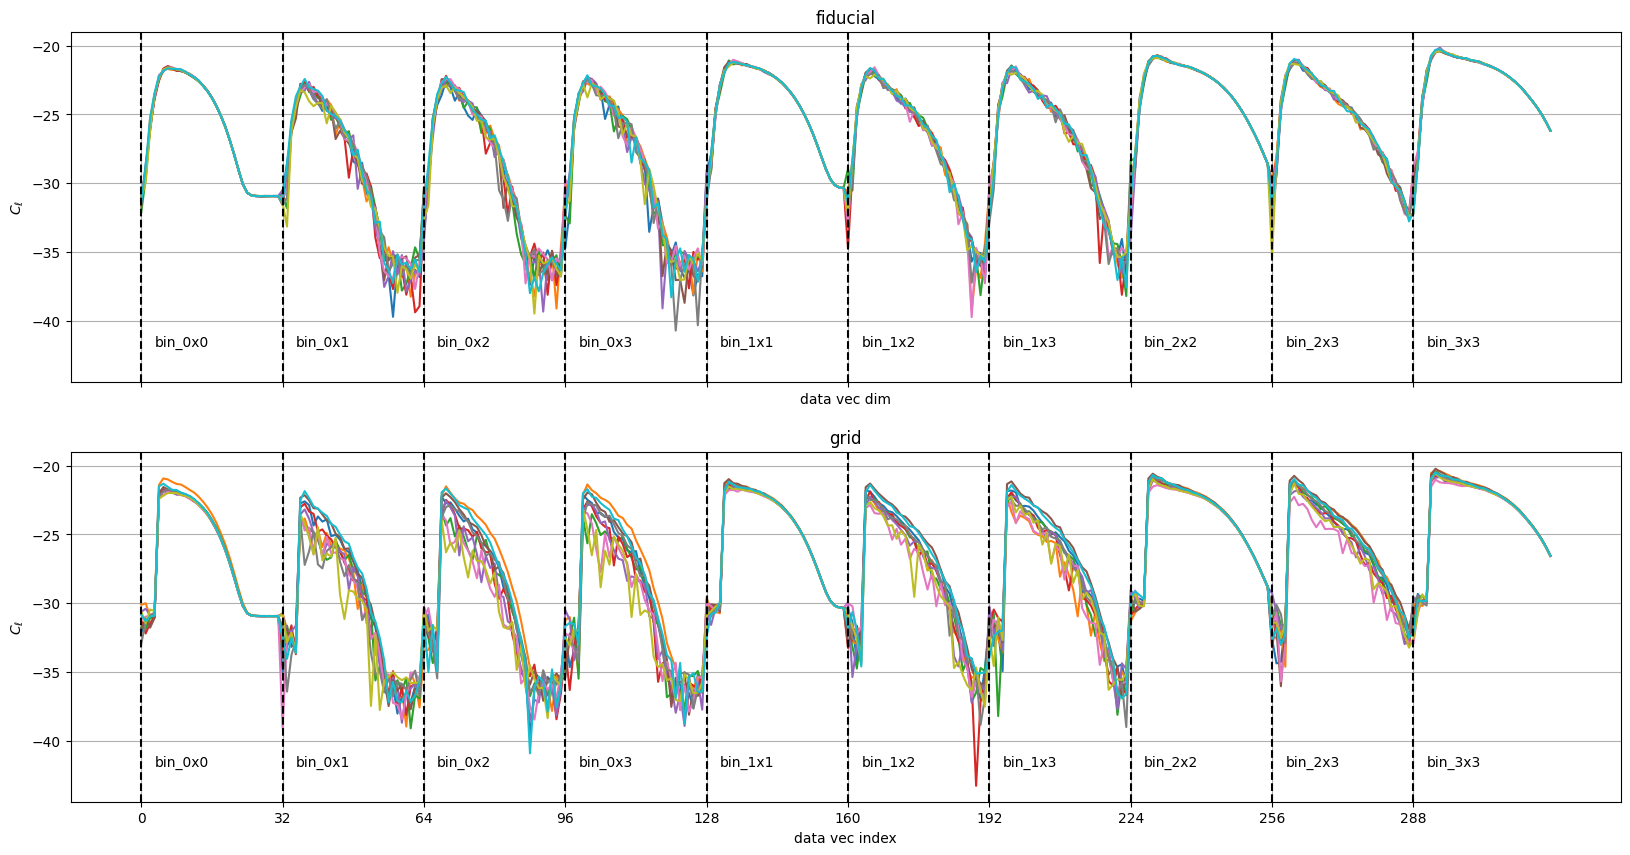

In [12]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

# hard cut dset

In [13]:
# l_mins = 8 * [30]
# l_maxs = [786, 1150, 1535, 1535, 267, 390, 509, 610]

# # def angle_to_ell(angles):
# #     return list(scales.angle_to_ell(np.array(angles), arcmin=True))
# # l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     dlss_conf=dlss_conf,
#     params=params,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     # n_bins=n_bins,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )

# functions and global constants

In [14]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = n_params

num_hidden_units = 1024
# num_hidden_units = 2048
num_layers = 2

dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    
    return mlp

In [15]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

# variational lower bound

In [16]:
learning_rate = 1e-4

summary_net = get_cl_summary_network()

if cosine_decay:
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate, decay_steps=n_steps, alpha=0.0
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
else:
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    restore_checkpoint=True,
    # restore_checkpoint=False,
)

# model.restore_model_from_checkpoint_path(
#     os.path.join(out_dir, "model", f"ckpt-{checkpoint_number}")
# )

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
)

25-05-15 23:28:37 base_model.p INF   Initializing with a normal Sequential model 
25-05-15 23:28:37 base_model.p INF   Network successfully restored from checkpoint /pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/model/ckpt-1. 
25-05-15 23:28:37 grid_model.p INF   Initialized the GridLossModel 
25-05-15 23:28:37 grid_model.p WAR   Mutual info loss, overwriting the checkpoint manager 
25-05-15 23:28:37 grid_model.p WAR   Mutual info loss, restoring the model again from within setup_grid_loss_step 
25-05-15 23:28:38 base_model.p INF   Network successfully restored from checkpoint /pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/model/ckpt-1. 
25-05-15 23:28:38 grid_model.p WAR   Using the mutual information loss with the variational estimator 
25-05-15 23:28:38 grid_model.p INF   Set up the training step of th

In [17]:
# train_model(model, eval_every=n_steps//10)

# save the results

In [18]:
# n_steps = 100_000
# out_dir = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}", "8,32mpc")
# os.makedirs(out_dir, exist_ok=True)
# print(out_dir)

In [19]:
# pred_file = os.path.join(out_dir, "preds.h5")
# print("pred_file", pred_file)

In [20]:
fidu_preds = model(out_dict["fidu/cls"])
grid_preds = model(out_dict["grid/cls/test"])

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    f.create_dataset(name="fidu/preds", data=fidu_preds)

print(f"Wrote to {pred_file}\n")
print(fidu_preds)

Wrote to /pscratch/sd/a/athomsen/run_files/v14/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/preds.h5

tf.Tensor(
[[ 0.07520043 -0.3762362   0.15206933 -0.20977004  0.19273588 -0.20052701]
 [-0.07638085 -0.37594634  0.25690696 -0.26320833  0.17939647 -0.16578539]
 [-0.06232628 -0.36918002  0.25346768 -0.2739705   0.21795206 -0.18821226]
 ...
 [ 0.10624951 -0.3833026   0.18085954 -0.10370719  0.18535109 -0.21199974]
 [-0.06138471 -0.41975123  0.25933284 -0.25417045  0.18950804 -0.23213163]
 [ 0.05165061 -0.39450118  0.21809414 -0.25508848  0.2837947  -0.23468989]], shape=(35920, 6), dtype=float32)


# external mocks

In [21]:
n_side = msfm_conf["analysis"]["n_side"]
n_pix = msfm_conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

i_rand = np.random.randint(0, grid_preds.shape[0], 100)

def evaluate_mock(out_label, lensing_file=None, clustering_file=None, nest_in=False, plot_diagnostics=False):
    # load the mock
    if lensing_file is not None:
        with h5py.File(lensing_file, "r") as f_in:
            gamma1 = []
            gamma2 = []
            for j in range(1,5):
                gamma1.append(f_in[f"metacal/raw_gamma1_bin{j}"])
                gamma2.append(f_in[f"metacal/raw_gamma2_bin{j}"])
            gamma1 = np.stack(gamma1, axis=-1)
            gamma2 = np.stack(gamma2, axis=-1)
            
            wl_map = np.stack([gamma1, gamma2], axis=-1)

        if plot_diagnostics:
            hp.mollview(gamma1[:,0], nest=nest_in, title="input gamma1")
            hp.mollview(gamma2[:,0], nest=nest_in, title="input gamma2")
    else:
        wl_map = np.zeros((n_pix,4,2))

    if clustering_file is not None:
        with h5py.File(clustering_file, "r") as f_in:
            gc_map = []
            for i in range(1,5):
                gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
            gc_map = np.stack(gc_map, axis=-1)

        if plot_diagnostics:
            hp.mollview(gc_map[:,0], nest=nest_in, title="input galaxy counts")
    else:
        gc_map = np.zeros((n_pix,4))

    # forward model
    obs_cl = preprocessing.get_preprocessed_cl_observation(
        wl_gamma_map=wl_map,
        gc_count_map=gc_map,
        # configuration
        msfm_conf=msfm_conf,
        dlss_conf=dlss_conf,
        base_dir=base_dir,
        nest_in=False,
        # selection
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=(with_lensing and with_clustering),
        # additional preprocessing
        apply_log=apply_log,
        standardize=standardize,
        # obs_label=out_label,
    )    

    # evaluate
    obs_pred = model(obs_cl, training=False)
    print(out_label, ": obs_pred =", obs_pred)

    if plot_diagnostics:
        tri = TriangleChain()
        tri.scatter(
            np.array(grid_preds)[i_rand], 
            scatter_kwargs={"s": 10, "marker": "o"}
        )
        tri.scatter(
            np.array(obs_pred), 
            scatter_kwargs={"s": 500, "marker": "*"},
            color="k"
        )
        fig, ax = plt.subplots()
        ax.plot(out_dict["grid/cls/test"][i_rand,:].T, alpha=0.5)
        ax.plot(np.squeeze(obs_cl), alpha=1, color="k", linestyle=":")
        ax.legend(loc="best")
        ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")

    # # save
    # with h5py.File(pred_file, "a") as f_out:
    #     if out_label in f_out:
    #         del f_out[out_label]
    #     f_out.create_dataset(name=out_label, data=obs_pred)


## Buzzard

### lensing

25-05-15 23:28:45 configuratio INF   Loaded the config 
25-05-15 23:28:45 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  94.82001756
 138.81748072 181.20805369 216.43286573] from the dlss config 
25-05-15 23:28:45 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
25-05-15 23:29:07 preprocessin INF   Adding white noise to the observation 
25-05-15 23:29:07 preprocessin INF   Using the bin indices [0, 1, 2, 3, 8, 9, 10, 15, 16, 21] 
25-05-15 23:29:07 preprocessin INF   Taking the logarithm of the absolute values. 
mocks/pred/Buzzard_0 : obs_pred = tf.Tensor([[ 0.18846916 -0.39802814  0.16802938  0.00514462  0.21816128 -0.28977844]], shape=(1, 6), dtype=float32)


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


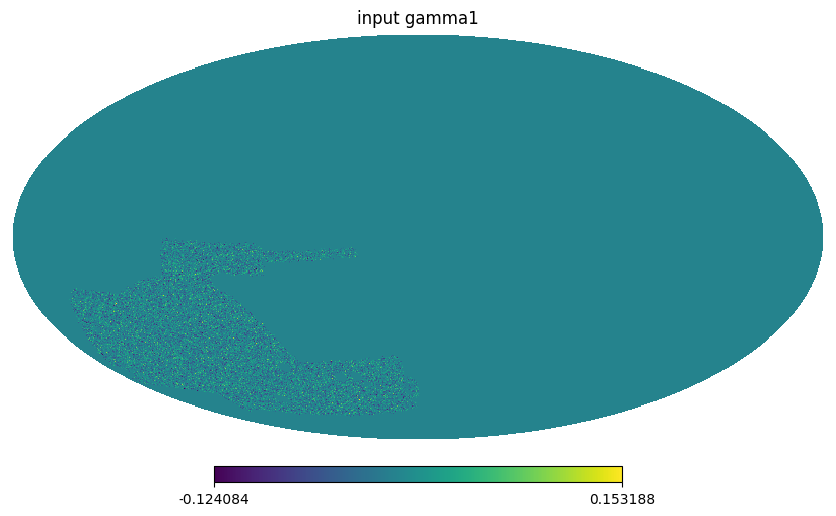

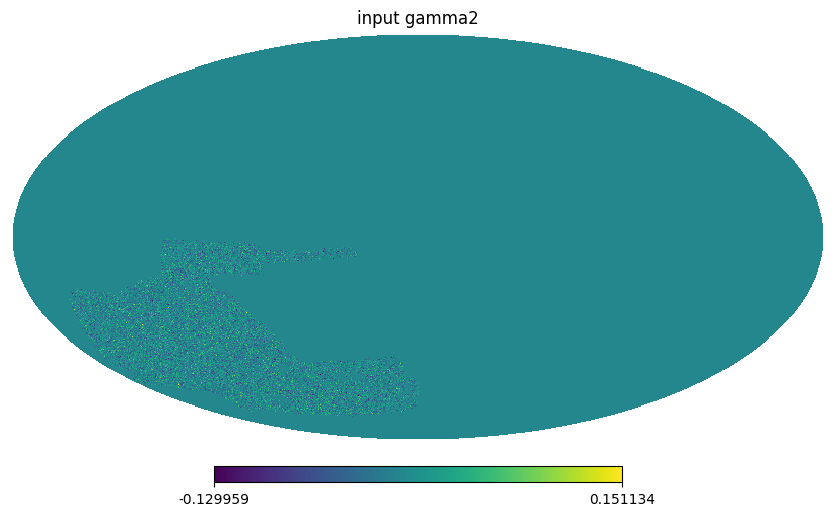

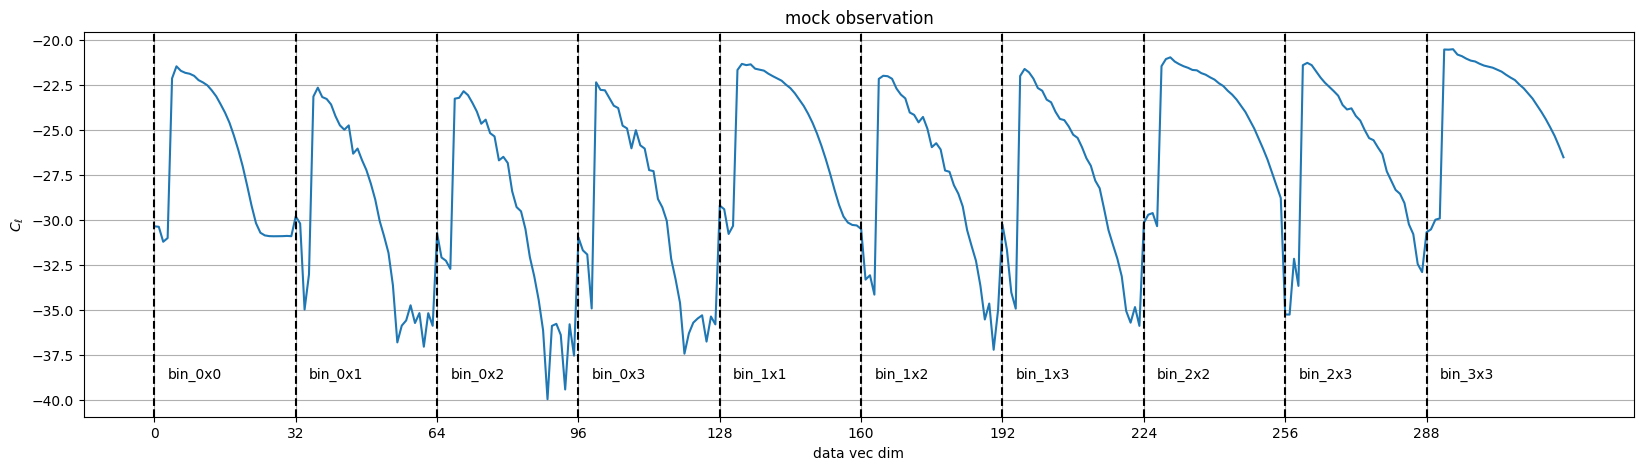

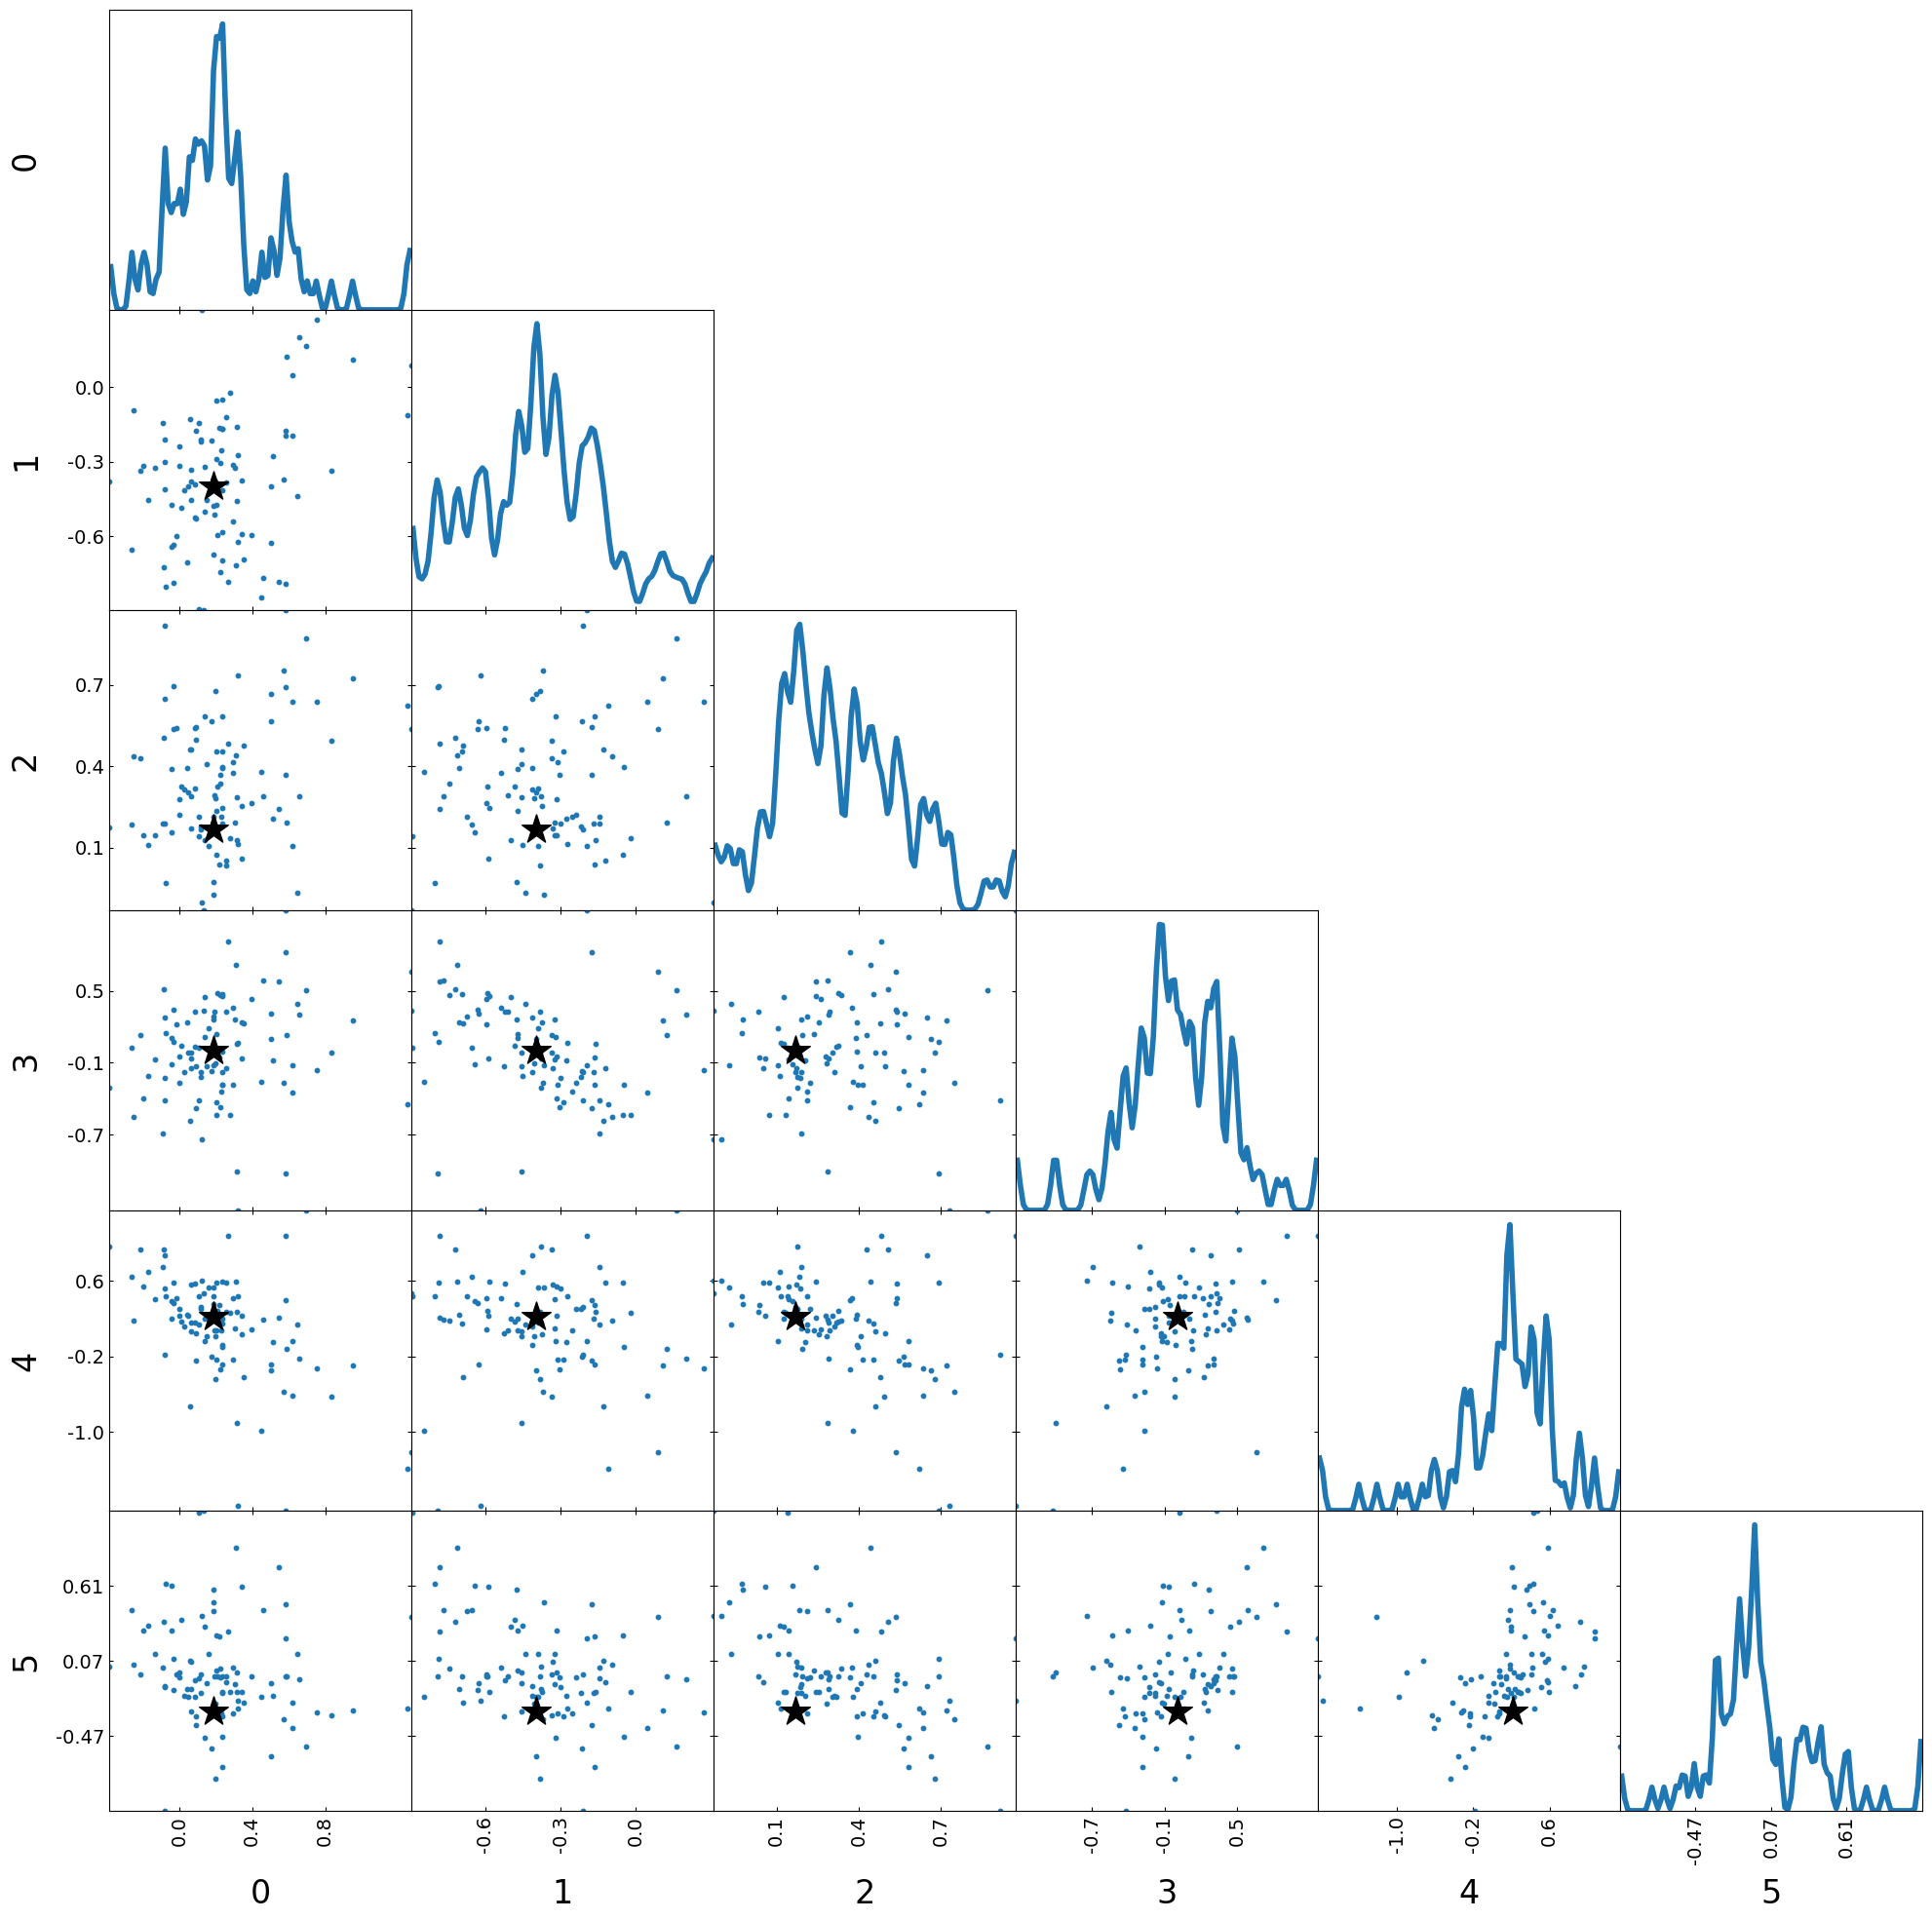

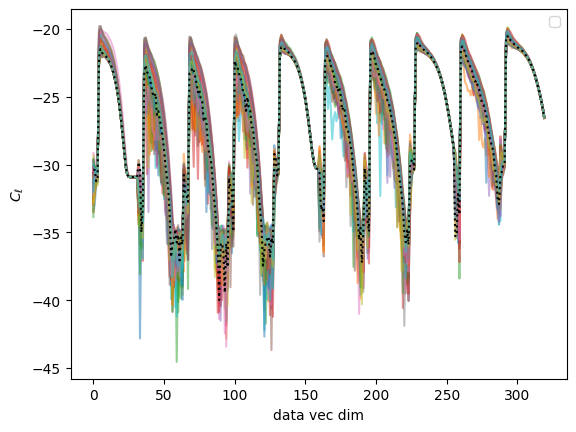

In [22]:
if with_lensing and not with_clustering:    
    buzzard_indices = list(range(0, 15))
    buzzard_indices.remove(1)
    buzzard_indices = [0]
    for i in buzzard_indices:
        out_label = f"mocks/pred/Buzzard_{i}"
        lensing_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"
        
        evaluate_mock(
            out_label, 
            lensing_file=lensing_file, 
            nest_in=False, 
            plot_diagnostics=True
        )

### clustering

In [ ]:
if not with_lensing and with_clustering:    
    # buzzard_indices = list(range(0, 15))
    # buzzard_indices.remove(1)
    # buzzard_indices = [0]
    I = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    J = [0, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 11, 11]
    K = ["a"] + 7 * ["a", "b"]

    # for i in buzzard_indices:
    for i, j, k in zip(I, J, K):
        out_label = f"mocks/pred/Buzzard_{i}"
        clustering_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_Buzzard_{j}_Y3{k}.h5"
        
        evaluate_mock(
            out_label, 
            clustering_file=clustering_file, 
            nest_in=False, 
            plot_diagnostics=True
        )

### combined

In [ ]:
if with_lensing and with_clustering:
    # buzzard_indices = list(range(0, 15))
    # buzzard_indices.remove(1)
    # buzzard_indices = [0]
    # for i in buzzard_indices:
    
    # for i, j, k in zip([0, 2, 3, 4], [0, 3, 3, 4], ["a", "a", "b", "a"]):
    I = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    J = [0, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 11, 11]
    K = ["a"] + 7 * ["a", "b"]
    for i, j, k in zip(I, J, K):
        out_label = f"mocks/pred/Buzzard_{i}"
        lensing_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"
        clustering_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_Buzzard_{j}_Y3{k}.h5"
        evaluate_mock(
            out_label, 
            lensing_file=lensing_file, 
            clustering_file=clustering_file,
            nest_in=False, 
            plot_diagnostics=False
        )

# plotting

In [ ]:
n_side = msfm_conf["analysis"]["n_side"]
n_pix = msfm_conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

i_rand = np.random.randint(0, grid_preds.shape[0], 100)

def get_obs_cls(out_label, lensing_file=None, clustering_file=None, nest_in=False):
    # load the mock
    if lensing_file is not None:
        with h5py.File(lensing_file, "r") as f_in:
            gamma1 = []
            gamma2 = []
            for j in range(1,5):
                gamma1.append(f_in[f"metacal/raw_gamma1_bin{j}"])
                gamma2.append(f_in[f"metacal/raw_gamma2_bin{j}"])
            gamma1 = np.stack(gamma1, axis=-1)
            gamma2 = np.stack(gamma2, axis=-1)
            
            wl_map = np.stack([gamma1, gamma2], axis=-1)
    else:
        wl_map = np.zeros((n_pix,4,2))

    if clustering_file is not None:
        with h5py.File(clustering_file, "r") as f_in:
            gc_map = []
            for i in range(1,5):
                gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
            gc_map = np.stack(gc_map, axis=-1)
    else:
        gc_map = np.zeros((n_pix,4))

    # forward model
    obs_cl = preprocessing.get_preprocessed_cl_observation(
        wl_gamma_map=wl_map,
        gc_count_map=gc_map,
        # configuration
        msfm_conf=msfm_conf,
        dlss_conf=dlss_conf,
        base_dir=base_dir,
        nest_in=False,
        # selection
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        # with_cross_z=with_cross_z,
        # with_cross_probe=(with_lensing and with_clustering),
        with_cross_z=False,
        with_cross_probe=False,
        # additional preprocessing
        apply_log=apply_log,
        standardize=standardize,
        # obs_label=out_label,
        make_plot=False,
    )    

    return obs_cl

In [ ]:
flock_cls = []
I = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
J = [0, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 11, 11]
K = ["a"] + 7 * ["a", "b"]
for i, j, k in zip(I, J, K):
    out_label = f"mocks/pred/Buzzard_{i}"
    lensing_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"
    clustering_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_Buzzard_{j}_Y3{k}.h5"
    obs_cls = get_obs_cls(
        out_label, 
        lensing_file=lensing_file, 
        clustering_file=clustering_file,
        nest_in=False
)
    flock_cls.append(obs_cls)
flock_cls = np.stack(flock_cls, axis=0)

In [ ]:
from msfm.utils import cross_statistics

In [ ]:
flock_cls = np.squeeze(flock_cls)
flock_cls.shape

In [ ]:
bin_size=msfm_conf["analysis"]["power_spectra"]["n_bins"] - 1
_, bin_names = cross_statistics.get_cross_bin_indices(
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    # with_cross_z=with_cross_z,
    # with_cross_probe=True,
    with_cross_z=False,
    with_cross_probe=False,
)

fig, ax = plt.subplots(figsize=(20, 10), sharex=True, nrows=2)

buzzard_indices = list(range(0, 15))
buzzard_indices.remove(1)
# buzzard_indices = [0]
for i in range(len(buzzard_indices)):
    mock = f"Buzzard_{buzzard_indices[i]}"

    ax[0].plot(flock_cls[i])
    ax[1].plot(flock_cls[i]/np.mean(flock_cls, axis=0) - 1)

ax[0].grid(True)
ax[1].grid(True)
ax[0].set(
    title="mock observation", xscale="linear", ylabel=r"$C_\ell$", ylim=(-35, -5)
)
ax[1].set(
     xlabel="data vec dim", ylabel=r"$\frac{C_\ell}{\bar{C}_\ell} - 1$", ylim=(-0.05, 0.05)
)

# cosmetics
if bin_size is not None:
    x = 0
    ticks = []
    for i, x in enumerate(np.arange(0, len(bin_names) * bin_size, bin_size)):
        ax[0].axvline(x, color="k", linestyle="--")
        ax[1].axvline(x, color="k", linestyle="--")
        ax[0].text(x + 3, 0.1, bin_names[i][4:], transform=ax[0].get_xaxis_transform())
        ticks.append(x)

    ax[1].set_xticks(ticks)

fig.savefig("./plots/Buzzards_auto.png", bbox_inches="tight", dpi=100)


In [ ]:
bin_size=msfm_conf["analysis"]["power_spectra"]["n_bins"] - 1
_, bin_names = cross_statistics.get_cross_bin_indices(
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=False,
    with_cross_probe=False,
    # with_cross_z=with_cross_z,
    # with_cross_probe=True,
)

buzzard_indices = list(range(0, 15))
buzzard_indices.remove(1)
# buzzard_indices = [0]
for i in range(len(buzzard_indices)):
    mock = f"Buzzard_{buzzard_indices[i]}"
    
    fig, ax = plt.subplots(figsize=(20, 10), sharex=True, nrows=2)

    ax[0].plot(flock_cls[i])
    ax[1].plot(flock_cls[i]/np.mean(flock_cls, axis=0) - 1)

    ax[0].grid(True)
    ax[1].grid(True)
    ax[0].set(
        title=mock, xscale="linear", ylabel=r"$C_\ell$", ylim=(-35, -5)
    )
    ax[1].set(
         xlabel="data vec dim", ylabel=r"$\frac{C_\ell}{\bar{C}_\ell} - 1$", ylim=(-0.05, 0.05)
    )

    # cosmetics
    if bin_size is not None:
        x = 0
        ticks = []
        for i, x in enumerate(np.arange(0, len(bin_names) * bin_size, bin_size)):
            ax[0].axvline(x, color="k", linestyle="--")
            ax[1].axvline(x, color="k", linestyle="--")
            ax[0].text(x + 3, 0.1, bin_names[i][4:], transform=ax[0].get_xaxis_transform())
            ticks.append(x)

        ax[1].set_xticks(ticks)

    fig.savefig("./plots/" + mock + "_auto.png", bbox_inches="tight", dpi=100)


# internal mocks

In [ ]:
# clustering_file = "/pscratch/sd/j/jbucko/DESY3/v13/linear_bias/clustering/maps/maps_for_compression_v13_clustering_True_lensing_False_grid_cosmo.pkl"
# with open(clustering_file, 'rb') as f:
#     jozef_maps = pickle.load(f)

# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# for i in range(jozef_maps.shape[0]):
#     for j in range(jozef_maps.shape[1]):
#         gc_map = jozef_maps[i,j]
        
#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         print(obs_cl.shape)
        

In [ ]:
# import pickle

# lensing_file = "/pscratch/sd/j/jbucko/DESY3/v13/linear_bias/lensing/maps/maps_for_compression_v13_clustering_False_lensing_True_grid_cosmo.pkl"
# with open(lensing_file, 'rb') as f:
#     data = pickle.load(f)

# print(data.shape)

In [ ]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


# OLD

In [ ]:
# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_from_g1g2.h5"
# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"

# i = 0
# buzzard_lensing_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"

# with h5py.File(buzzard_lensing_file, "r") as f_in:
#     gamma1 = []
#     gamma2 = []
#     for i in range(1,5):
#         gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
#         gamma2.append(f_in[f"metacal/raw_gamma2_bin{i}"])
#     gamma1 = np.stack(gamma1, axis=-1)
#     gamma2 = np.stack(gamma2, axis=-1)
    
#     wl_map = np.stack([gamma1, gamma2], axis=-1)

# nest_in = False
# # hp.mollview(gamma1[:,0], nest=nest_in, title="input gamma1")
# # hp.mollview(gamma2[:,0], nest=nest_in, title="input gamma2")

# obs, obs_cls, data_vec_pix = observation.forward_model_observation_map(
#     wl_gamma_map=wl_map,
#     conf=msfm_conf,
#     apply_norm=False,
#     with_padding=True,
#     nest_in=nest_in,
# )

# n_pix = msfm_conf["analysis"]["n_pix"]
# obs_map = np.zeros((n_pix, obs.shape[-1]))
# obs_map[data_vec_pix] = obs
# hp.mollview(obs_map[:,0], nest=True, title="output data vector")

### multiple Buzzards

In [ ]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# i_rand = np.random.randint(0, grid_preds.shape[0], 100)

# buzzard_indices = list(range(0, 15))
# buzzard_indices.remove(1)

# for i in buzzard_indices:
#     obs_label = f"Buzzard_{i}"
#     buzzard_lensing_file = f"/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/{i}/DESY3_mock_observation_buzzard_flock_v14_shear_noise+WL.h5"
    
#     with h5py.File(buzzard_lensing_file, "r") as f_in:
#         gamma1 = []
#         gamma2 = []
#         for i in range(1,5):
#             gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
#             gamma2.append(f_in[f"metacal/raw_gamma2_bin{i}"])
#         gamma1 = np.stack(gamma1, axis=-1)
#         gamma2 = np.stack(gamma2, axis=-1)
        
#         wl_map = np.stack([gamma1, gamma2], axis=-1)

#     # get rid of underflows/hp.UNSEEN
#     wl_map = np.where(wl_map < -10, 0.0, wl_map)
    
#     obs_cl = preprocessing.get_preprocessed_cl_observation(
#         wl_gamma_map=wl_map,
#         gc_count_map=np.zeros((n_pix,4)),
#         # configuration
#         msfm_conf=msfm_conf,
#         dlss_conf=dlss_conf,
#         base_dir=base_dir,
#         nest_in=False,
#         # selection
#         with_lensing=with_lensing,
#         with_clustering=with_clustering,
#         with_cross_z=with_cross_z,
#         with_cross_probe=(with_lensing and with_clustering),
#         # additional preprocessing
#         apply_log=apply_log,
#         standardize=standardize,
#     )    

#     obs_pred = model(obs_cl)
#     print("\n", obs_label, obs_pred, "\n")

#     with h5py.File(pred_file, "a") as f_out:
#         out_label = f"mocks/pred/{obs_label}" 
#         if out_label in f_out:
#             del f_out[out_label]
#         f_out.create_dataset(name=out_label, data=obs_pred)

#     # debug
#     fig, ax = plt.subplots()
#     # ax.plot(out_dict["grid/cls/test"][0,:], label="grid 0", alpha=0.5)
#     ax.plot(out_dict["grid/cls/test"][i_rand,:].T, alpha=0.5)
#     ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=1.0, color="k", linestyle=":")
#     ax.legend(loc="best")
#     ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")
    
#     tri = TriangleChain()
#     tri.scatter(
#         np.array(grid_preds)[i_rand], 
#         scatter_kwargs={"s": 10, "marker": "o"}
#     )
#     tri.scatter(
#         np.array(obs_pred), 
#         scatter_kwargs={"s": 500, "marker": "*"},
#         color="k"
#     )


### clustering

In [ ]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


### Buzzard flock

In [ ]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_files = os.listdir(buzzard_flock_dir)

# with h5py.File(pred_file, "a") as f_out:
#     for buzzard_flock_file in buzzard_flock_files:
#         obs_file = os.path.join(buzzard_flock_dir, buzzard_flock_file)
#         obs_label = buzzard_flock_file[23:-3]
    
#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         # f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)

#         out_label = f"mocks/pred/{obs_label}" 
#         if out_label in f_out:
#             del f_out[out_label]
#         f_out.create_dataset(name=out_label, data=obs_pred)



# OLD